In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Test\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1.Collect the Dataset

In [2]:
df=pd.read_csv('C:/Users/Test/OneDrive/Desktop/Train_data.csv')
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,tcp,exec,RSTO,0,0,0,0,0,0,...,7,0.03,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25188,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,39,1.00,0.00,1.00,0.18,0.00,0.00,0.00,0.00,anomaly
25189,0,tcp,private,REJ,0,0,0,0,0,0,...,13,0.05,0.07,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25190,0,tcp,nnsp,S0,0,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [4]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2.Data Preprocessing

In [5]:
df.isnull().sum() 

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [6]:
df.duplicated().sum() #finding duplicate values 

0

In [7]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [8]:
df.corr()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
duration,1.000000,0.084864,0.013258,-0.001012,-0.010358,-0.000486,0.004202,0.011108,-0.063703,0.095215,...,0.055174,-0.112530,-0.119321,0.263489,0.240970,-0.025485,-0.066513,-0.066240,0.187070,0.208435
src_bytes,0.084864,1.000000,0.003611,-0.000090,-0.000916,-0.000062,0.000995,-0.000260,-0.002040,-0.000196,...,-0.009764,-0.008520,-0.006776,0.001026,0.002316,-0.001238,-0.006346,-0.006227,-0.002130,0.006190
dst_bytes,0.013258,0.003611,1.000000,-0.000350,-0.003586,0.000345,0.002539,0.005197,0.012704,0.035852,...,-0.030930,-0.000980,0.022392,-0.012971,0.024078,-0.006006,-0.015584,-0.014543,-0.014094,-0.012803
land,-0.001012,-0.000090,-0.000350,1.000000,-0.000813,-0.000056,-0.000819,-0.000234,-0.007196,-0.000195,...,-0.016340,-0.008743,0.009531,-0.003929,0.024635,0.053037,0.014291,0.005596,-0.003432,-0.003335
wrong_fragment,-0.010358,-0.000916,-0.003586,-0.000813,1.000000,-0.000575,-0.008386,-0.002392,-0.073674,-0.001995,...,0.040020,-0.047256,-0.051845,0.053177,0.034670,-0.020174,-0.053786,-0.057230,0.027718,-0.034143
urgent,-0.000486,-0.000062,0.000345,-0.000056,-0.000575,1.000000,0.002346,-0.000165,0.007801,0.002886,...,0.004612,-0.006324,-0.007014,-0.002105,-0.003013,-0.001815,-0.004044,-0.003953,-0.002427,-0.002358
hot,0.004202,0.000995,0.002539,-0.000819,-0.008386,0.002346,1.000000,0.004893,0.113115,0.002005,...,-0.009083,-0.048495,-0.033442,-0.007962,-0.030640,-0.021170,-0.055628,-0.056255,-0.027628,-0.029719
num_failed_logins,0.011108,-0.000260,0.005197,-0.000234,-0.002392,-0.000165,0.004893,1.000000,-0.006872,0.015787,...,-0.026460,-0.022315,-0.003336,0.000298,-0.008910,-0.007551,-0.009527,-0.010238,0.016791,0.018693
logged_in,-0.063703,-0.002040,0.012704,-0.007196,-0.073674,0.007801,0.113115,-0.006872,1.000000,0.027083,...,-0.395905,0.624839,0.607379,-0.255820,-0.159278,-0.057390,-0.490450,-0.492446,-0.274430,-0.270507
num_compromised,0.095215,-0.000196,0.035852,-0.000195,-0.001995,0.002886,0.002005,0.015787,0.027083,1.000000,...,-0.015637,-0.018220,-0.011794,0.001757,-0.004146,0.013608,-0.007911,-0.007716,-0.007199,-0.004361


### univariate analysis

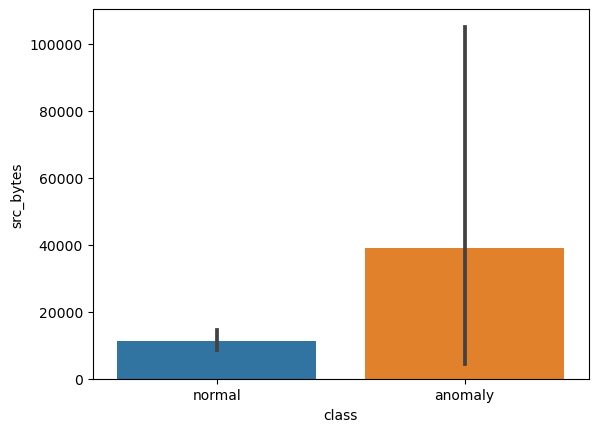

In [9]:
sns.barplot(data=df,x='class',y='src_bytes')
plt.show()

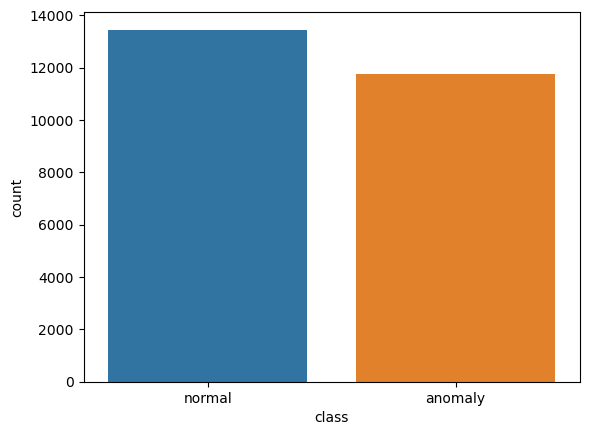

In [10]:
sns.countplot(data=df,x='class')
plt.show()

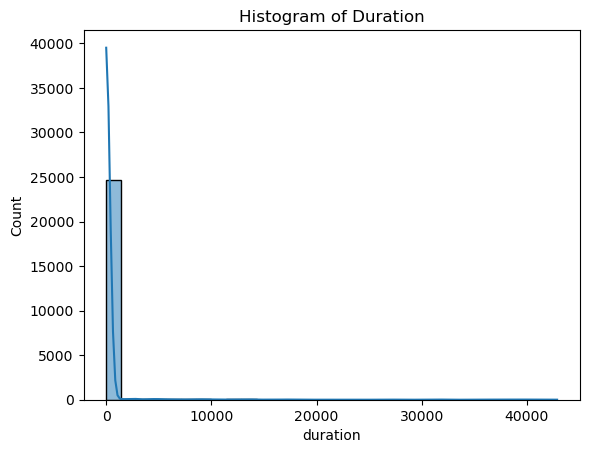

In [11]:
sns.histplot(data=df, x='duration', bins=30, kde=True)
plt.title('Histogram of Duration')
plt.show()


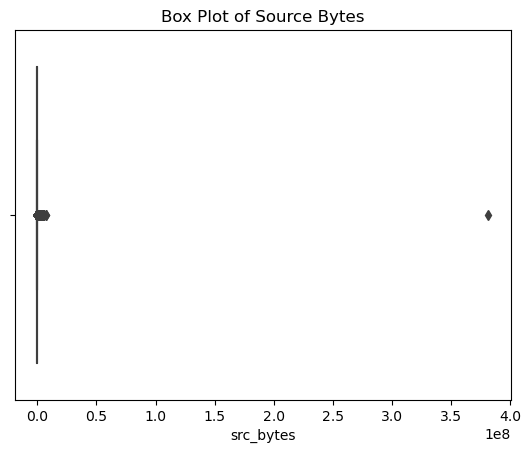

In [12]:
sns.boxplot(data=df, x='src_bytes')
plt.title('Box Plot of Source Bytes')
plt.show()


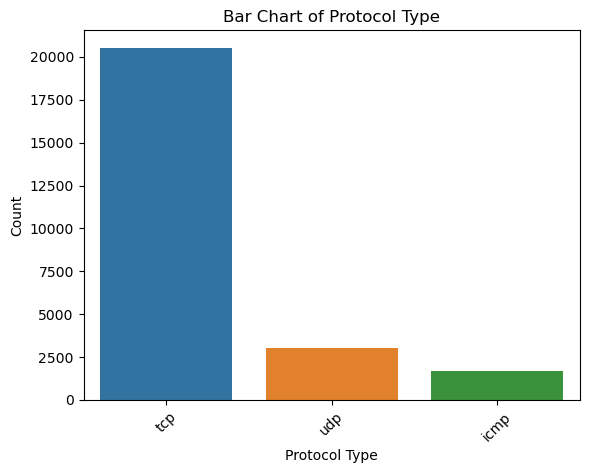

In [13]:
sns.barplot(data=df, x=df['protocol_type'].value_counts().index, y=df['protocol_type'].value_counts().values)
plt.title('Bar Chart of Protocol Type')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


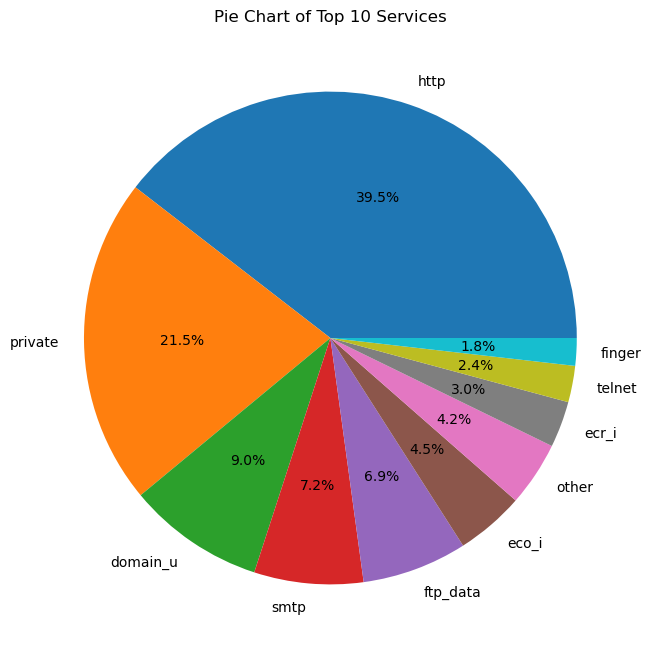

In [14]:
df['service'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Pie Chart of Top 10 Services')
plt.ylabel('')
plt.show()


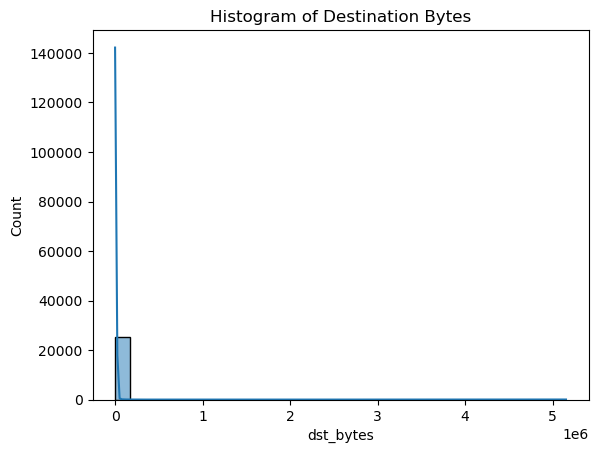

In [15]:
sns.histplot(data=df, x='dst_bytes', bins=30, kde=True)
plt.title('Histogram of Destination Bytes')
plt.show()


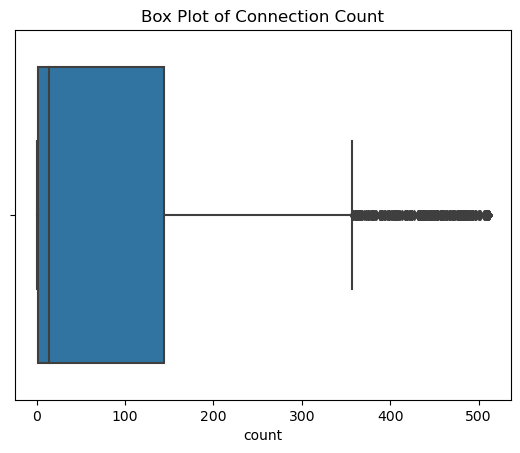

In [16]:
sns.boxplot(data=df, x='count')
plt.title('Box Plot of Connection Count')
plt.show()


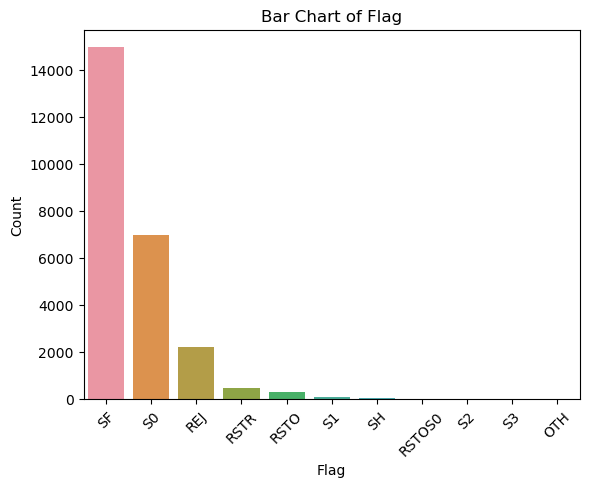

In [17]:
sns.barplot(data=df, x=df['flag'].value_counts().index, y=df['flag'].value_counts().values)
plt.title('Bar Chart of Flag')
plt.xlabel('Flag')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


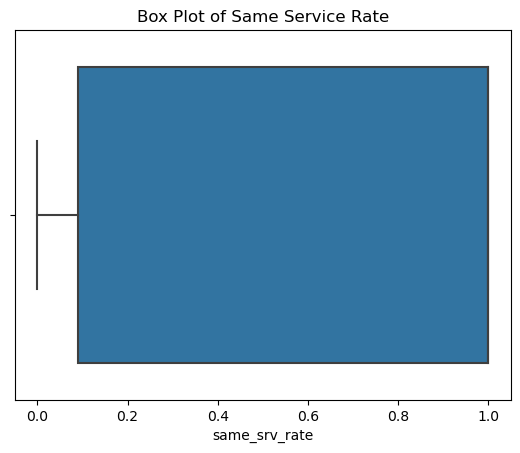

In [18]:
sns.boxplot(data=df, x='same_srv_rate')
plt.title('Box Plot of Same Service Rate')
plt.show()


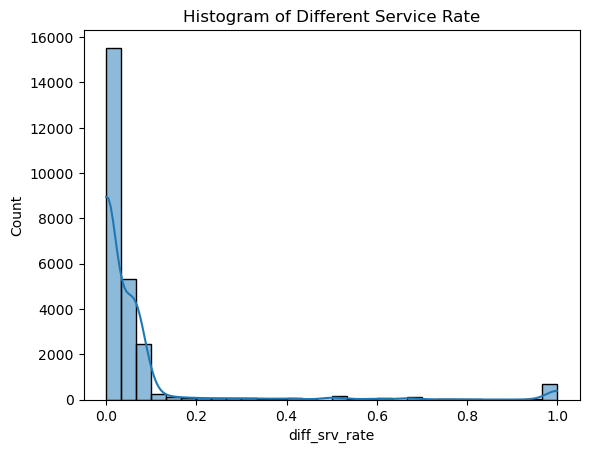

In [19]:
sns.histplot(data=df, x='diff_srv_rate', bins=30, kde=True)
plt.title('Histogram of Different Service Rate')
plt.show()


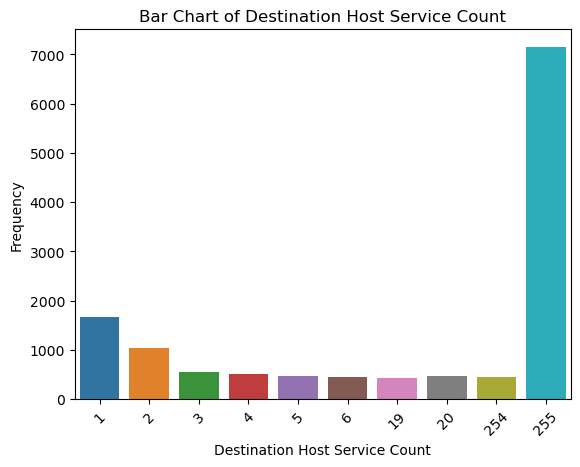

In [20]:
sns.barplot(data=df, x=df['dst_host_srv_count'].value_counts().index[:10], 
            y=df['dst_host_srv_count'].value_counts().values[:10])
plt.title('Bar Chart of Destination Host Service Count')
plt.xlabel('Destination Host Service Count')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


### BiVariate Analysis

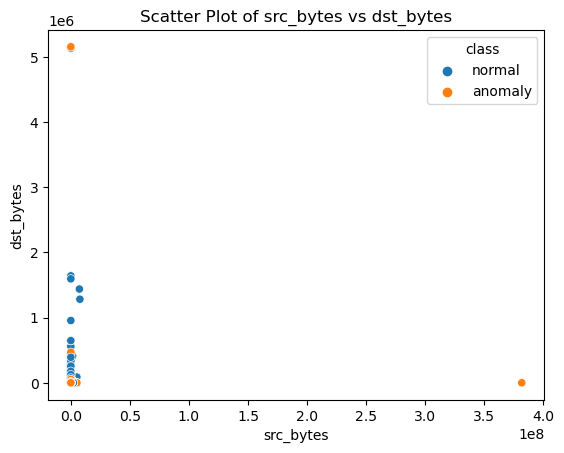

In [21]:
# Scatter Plot: Relationship between 'src_bytes' and 'dst_bytes'
sns.scatterplot(data=df, x='src_bytes', y='dst_bytes', hue='class')
plt.title("Scatter Plot of src_bytes vs dst_bytes")
plt.show()


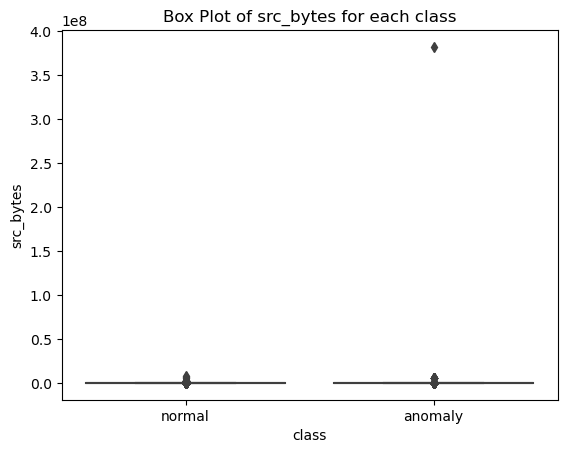

In [22]:
# Box Plot: 'src_bytes' distribution across different 'class'
sns.boxplot(data=df, x='class', y='src_bytes')
plt.title("Box Plot of src_bytes for each class")
plt.xticks(rotation=0)
plt.show()


### MultiVariate Analysis

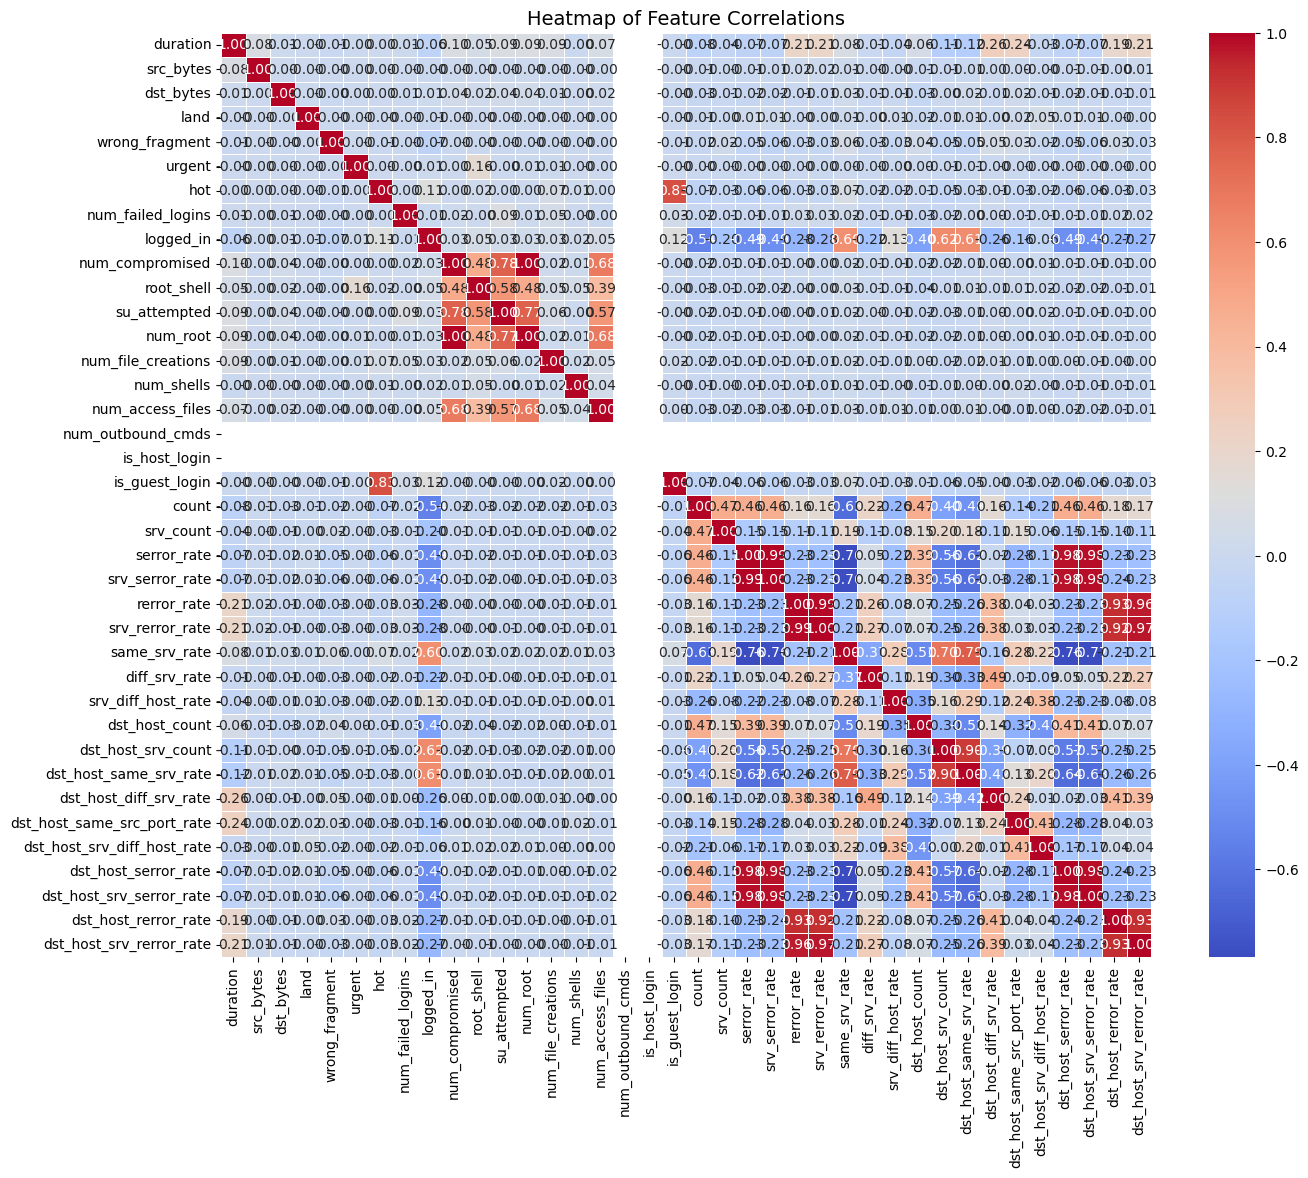

In [23]:
corr_matrix = df.corr()
plt.figure(figsize=(15, 12))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Feature Correlations", fontsize=14)
plt.show()


In [24]:
selected_columns = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count',
                    'protocol_type', 'service', 'flag', 'same_srv_rate', 'diff_srv_rate', 
                    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'class']
df_selected = df[selected_columns] # new DataFrame with only selected columms
df_selected

,src_bytes,dst_bytes,count,srv_count,dst_host_count,protocol_type,service,flag,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_diff_srv_rate,class
0,491,0,2,2,150,tcp,ftp_data,SF,1.00,0.00,0.17,0.03,normal
1,146,0,13,1,255,udp,other,SF,0.08,0.15,0.00,0.60,normal
2,0,0,123,6,255,tcp,private,S0,0.05,0.07,0.10,0.05,anomaly
3,232,8153,5,5,30,tcp,http,SF,1.00,0.00,1.00,0.00,normal
4,199,420,30,32,255,tcp,http,SF,1.00,0.00,1.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,0,100,7,255,tcp,exec,RSTO,0.07,0.07,0.03,0.06,anomaly
25188,334,0,1,1,1,tcp,ftp_data,SF,1.00,0.00,1.00,0.00,anomaly
25189,0,0,105,7,255,tcp,private,REJ,0.07,0.07,0.05,0.07,anomaly
25190,0,0,129,18,255,tcp,nnsp,S0,0.14,0.06,0.08,0.06,anomaly


In [25]:
df_selected.shape

(25192, 13)

In [26]:
df_selected.columns

Index(['src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count',
       'protocol_type', 'service', 'flag', 'same_srv_rate', 'diff_srv_rate',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'class'],
      dtype='object')

In [27]:
df_selected

,src_bytes,dst_bytes,count,srv_count,dst_host_count,protocol_type,service,flag,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_diff_srv_rate,class
0,491,0,2,2,150,tcp,ftp_data,SF,1.00,0.00,0.17,0.03,normal
1,146,0,13,1,255,udp,other,SF,0.08,0.15,0.00,0.60,normal
2,0,0,123,6,255,tcp,private,S0,0.05,0.07,0.10,0.05,anomaly
3,232,8153,5,5,30,tcp,http,SF,1.00,0.00,1.00,0.00,normal
4,199,420,30,32,255,tcp,http,SF,1.00,0.00,1.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,0,100,7,255,tcp,exec,RSTO,0.07,0.07,0.03,0.06,anomaly
25188,334,0,1,1,1,tcp,ftp_data,SF,1.00,0.00,1.00,0.00,anomaly
25189,0,0,105,7,255,tcp,private,REJ,0.07,0.07,0.05,0.07,anomaly
25190,0,0,129,18,255,tcp,nnsp,S0,0.14,0.06,0.08,0.06,anomaly


In [28]:
df_selected.isnull().sum()

src_bytes                 0
dst_bytes                 0
count                     0
srv_count                 0
dst_host_count            0
protocol_type             0
service                   0
flag                      0
same_srv_rate             0
diff_srv_rate             0
dst_host_same_srv_rate    0
dst_host_diff_srv_rate    0
class                     0
dtype: int64

In [29]:
import warnings 
warnings.filterwarnings('ignore')

In [30]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder instance
encoder = LabelEncoder()

# Encode categorical columns
df_selected['protocol_type'] = encoder.fit_transform(df_selected['protocol_type'])
df_selected['service'] = encoder.fit_transform(df_selected['service'])
df_selected['flag'] = encoder.fit_transform(df_selected['flag'])

# Display the updated dataframe
df_selected


,src_bytes,dst_bytes,count,srv_count,dst_host_count,protocol_type,service,flag,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_diff_srv_rate,class
0,491,0,2,2,150,1,19,9,1.00,0.00,0.17,0.03,normal
1,146,0,13,1,255,2,41,9,0.08,0.15,0.00,0.60,normal
2,0,0,123,6,255,1,46,5,0.05,0.07,0.10,0.05,anomaly
3,232,8153,5,5,30,1,22,9,1.00,0.00,1.00,0.00,normal
4,199,420,30,32,255,1,22,9,1.00,0.00,1.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,0,100,7,255,1,16,2,0.07,0.07,0.03,0.06,anomaly
25188,334,0,1,1,1,1,19,9,1.00,0.00,1.00,0.00,anomaly
25189,0,0,105,7,255,1,46,1,0.07,0.07,0.05,0.07,anomaly
25190,0,0,129,18,255,1,38,5,0.14,0.06,0.08,0.06,anomaly


In [31]:
x=df_selected.drop('class',axis=1)
x

,src_bytes,dst_bytes,count,srv_count,dst_host_count,protocol_type,service,flag,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_diff_srv_rate
0,491,0,2,2,150,1,19,9,1.00,0.00,0.17,0.03
1,146,0,13,1,255,2,41,9,0.08,0.15,0.00,0.60
2,0,0,123,6,255,1,46,5,0.05,0.07,0.10,0.05
3,232,8153,5,5,30,1,22,9,1.00,0.00,1.00,0.00
4,199,420,30,32,255,1,22,9,1.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,0,100,7,255,1,16,2,0.07,0.07,0.03,0.06
25188,334,0,1,1,1,1,19,9,1.00,0.00,1.00,0.00
25189,0,0,105,7,255,1,46,1,0.07,0.07,0.05,0.07
25190,0,0,129,18,255,1,38,5,0.14,0.06,0.08,0.06


In [32]:
x.dtypes

src_bytes                   int64
dst_bytes                   int64
count                       int64
srv_count                   int64
dst_host_count              int64
protocol_type               int32
service                     int32
flag                        int32
same_srv_rate             float64
diff_srv_rate             float64
dst_host_same_srv_rate    float64
dst_host_diff_srv_rate    float64
dtype: object

In [33]:
y=df_selected[['class']]
y

,class
0,normal
1,normal
2,anomaly
3,normal
4,normal
...,...
25187,anomaly
25188,anomaly
25189,anomaly
25190,anomaly


In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
df_selected.src_bytes=scaler.fit_transform(df_selected[['src_bytes']])
df_selected.dst_bytes=scaler.fit_transform(df_selected[['dst_bytes']])
df_selected.count=scaler.fit_transform(df_selected[['count']])
df_selected.srv_count=scaler.fit_transform(df_selected[['srv_count']])
df_selected.dst_host_count=scaler.fit_transform(df_selected[['dst_host_count']])
# df_selected.protocol_type=scaler.fit_transform(df_selected[['protocol_type']])
# df_selected.service=scaler.fit_transform(df_selected[['service']])
# df_selected.flag=scaler.fit_transform(df_selected[['flag']])
df_selected.same_srv_rate=scaler.fit_transform(df_selected[['same_srv_rate']])
df_selected.diff_srv_rate=scaler.fit_transform(df_selected[['diff_srv_rate']])
df_selected.dst_host_same_srv_rate=scaler.fit_transform(df_selected[['dst_host_same_srv_rate']])
df_selected.dst_host_diff_srv_rate=scaler.fit_transform(df_selected[['dst_host_diff_srv_rate']])

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=0,stratify=y)

In [39]:
x_train.shape

(20153, 12)

In [40]:
y_train.shape

(20153, 1)

In [41]:
x

,src_bytes,dst_bytes,count,srv_count,dst_host_count,protocol_type,service,flag,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_diff_srv_rate
0,491,0,2,2,150,1,19,9,1.00,0.00,0.17,0.03
1,146,0,13,1,255,2,41,9,0.08,0.15,0.00,0.60
2,0,0,123,6,255,1,46,5,0.05,0.07,0.10,0.05
3,232,8153,5,5,30,1,22,9,1.00,0.00,1.00,0.00
4,199,420,30,32,255,1,22,9,1.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,0,100,7,255,1,16,2,0.07,0.07,0.03,0.06
25188,334,0,1,1,1,1,19,9,1.00,0.00,1.00,0.00
25189,0,0,105,7,255,1,46,1,0.07,0.07,0.05,0.07
25190,0,0,129,18,255,1,38,5,0.14,0.06,0.08,0.06


In [42]:
y

,class
0,normal
1,normal
2,anomaly
3,normal
4,normal
...,...
25187,anomaly
25188,anomaly
25189,anomaly
25190,anomaly


In [43]:
y.value_counts()

class  
normal     13449
anomaly    11743
dtype: int64

In [44]:
print(y_train.value_counts()) 

class  
normal     10759
anomaly     9394
dtype: int64


## 3.Model Building

### 1.Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
lr_preds = lr_model.predict(x_test)
lr_accuracy = accuracy_score(y_test, lr_preds)
print("Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.8714030561619369
              precision    recall  f1-score   support

     anomaly       0.99      0.73      0.84      2349
      normal       0.81      0.99      0.89      2690

    accuracy                           0.87      5039
   macro avg       0.90      0.86      0.87      5039
weighted avg       0.89      0.87      0.87      5039



### 2.Support Vector Classifier


========= Support Vector Classifier =========
Accuracy: 0.14864060329430442
Classification Report:
               precision    recall  f1-score   support

     anomaly       0.09      0.09      0.09      2349
      normal       0.20      0.20      0.20      2690

    accuracy                           0.15      5039
   macro avg       0.15      0.15      0.15      5039
weighted avg       0.15      0.15      0.15      5039



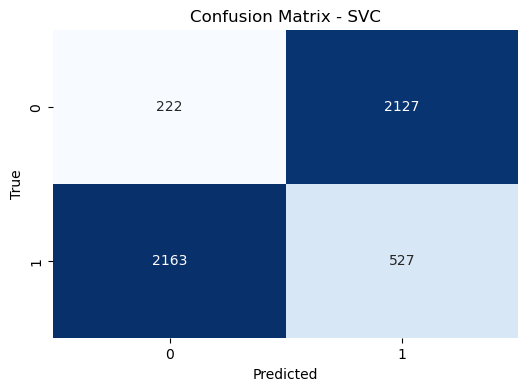

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
svc = SVC(kernel='poly', gamma=1.0)
svc.fit(x_train, y_train)
svc_preds = svc.predict(x_test)
print("\n========= Support Vector Classifier =========")
print("Accuracy:", accuracy_score(y_test, svc_preds))
print("Classification Report:\n", classification_report(y_test, svc_preds))
cm = confusion_matrix(y_test, svc_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix - SVC")
plt.show()

### 3.Bagging Classifier

In [47]:
df_selected.head(5)

,src_bytes,dst_bytes,count,srv_count,dst_host_count,protocol_type,service,flag,same_srv_rate,diff_srv_rate,dst_host_same_srv_rate,dst_host_diff_srv_rate,class
0,-0.009889,-0.039310,2,-0.354628,-0.328634,1,19,9,0.772109,-0.349282,-0.779157,-0.280673,normal
1,-0.010032,-0.039310,13,-0.368427,0.732059,2,41,9,-1.320567,0.490836,-1.157831,2.764403,normal
2,-0.010093,-0.039310,123,-0.299430,0.732059,1,46,5,-1.388806,0.042773,-0.935081,-0.173828,anomaly
3,-0.009996,0.052473,5,-0.313230,-1.540854,1,22,9,0.772109,-0.349282,1.069663,-0.440940,normal
4,-0.010010,-0.034582,30,0.059355,0.732059,1,22,9,0.772109,-0.349282,1.069663,-0.440940,normal


In [48]:
df['protocol_type'].value_counts()

tcp     20526
udp      3011
icmp     1655
Name: protocol_type, dtype: int64


========= Bagging Classifier =========
Accuracy: 0.9952371502282199
Classification Report:
               precision    recall  f1-score   support

     anomaly       1.00      0.99      0.99      2349
      normal       0.99      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



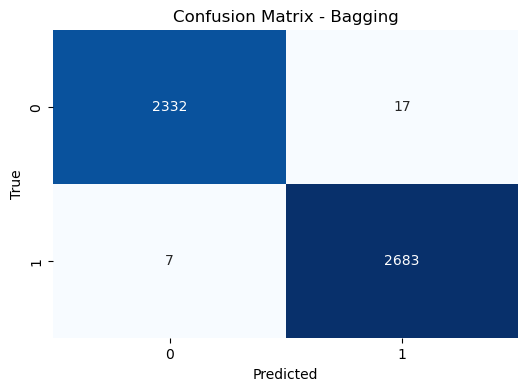

In [49]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
bagging = BaggingClassifier(n_estimators=50, random_state=42)
bagging.fit(x_train, y_train)
bagging_preds = bagging.predict(x_test)
print("\n========= Bagging Classifier =========")
print("Accuracy:", accuracy_score(y_test, bagging_preds))
print("Classification Report:\n", classification_report(y_test, bagging_preds))
cm = confusion_matrix(y_test, bagging_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix - Bagging")
plt.show()

### 4.K-Neighbour Classifier


========= K-Nearest Neighbors =========
Accuracy: 0.9859099027584838
Classification Report:
               precision    recall  f1-score   support

     anomaly       0.99      0.98      0.98      2349
      normal       0.98      0.99      0.99      2690

    accuracy                           0.99      5039
   macro avg       0.99      0.99      0.99      5039
weighted avg       0.99      0.99      0.99      5039



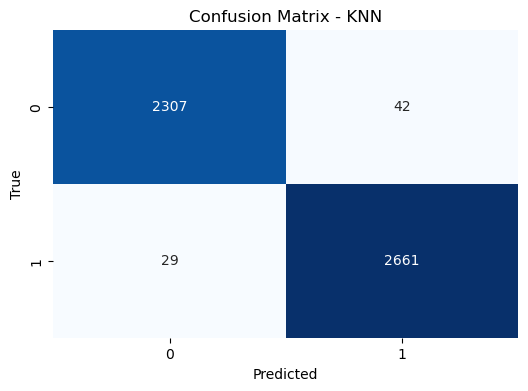

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
knn_preds = knn.predict(x_test)
print("\n========= K-Nearest Neighbors =========")
print("Accuracy:", accuracy_score(y_test, knn_preds))
print("Classification Report:\n", classification_report(y_test, knn_preds))
cm = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title("Confusion Matrix - KNN")
plt.show()

## 4.performance Testing

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define your models correctly before using them
logistic_regression = LogisticRegression()
bagging_classifier = BaggingClassifier(n_estimators=50, random_state=42)
svc = SVC(kernel='poly', gamma=1.0, probability=True)  # Enable probability for ROC AUC
knc = KNeighborsClassifier(n_neighbors=5)

# Store models in a dictionary
models = {
    'Logistic Regression': logistic_regression,
    'Bagging Classifier': bagging_classifier,
    'Support Vector Machine': svc,
    'K-Neighbors Classifier': knc
}

# Initialize dictionary to store results
metrics = ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
results = {metric: {} for metric in metrics}

# Train & Evaluate each model
for model_name, model in models.items():
    model.fit(x_train, y_train)  # Train the model

    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Compute metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    # Compute ROC AUC only if model supports probability predictions
    if hasattr(model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])
    else:
        roc_auc = "N/A"  # SVM needs `probability=True` to support predict_proba

    # Store results
    results['Train Accuracy'][model_name] = train_accuracy
    results['Test Accuracy'][model_name] = test_accuracy
    results['Precision'][model_name] = precision
    results['Recall'][model_name] = recall
    results['F1 Score'][model_name] = f1
    results['ROC AUC'][model_name] = roc_auc

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

# Display the performance table
print("\n========== Model Performance Summary ==========")
print(results_df)



========== Model Performance Summary ==========
                        Train Accuracy  Test Accuracy  Precision    Recall  \
Logistic Regression           0.871979       0.871403   0.892195  0.871403   
Bagging Classifier            0.999901       0.995237   0.995244  0.995237   
Support Vector Machine        0.147571       0.148641   0.149394  0.148641   
K-Neighbors Classifier        0.993103       0.985910   0.985918  0.985910   

                        F1 Score   ROC AUC  
Logistic Regression     0.868457  0.865284  
Bagging Classifier      0.995236  0.998833  
Support Vector Machine  0.149010  0.500000  
K-Neighbors Classifier  0.985907  0.994892  


<Figure size 1500x1000 with 0 Axes>

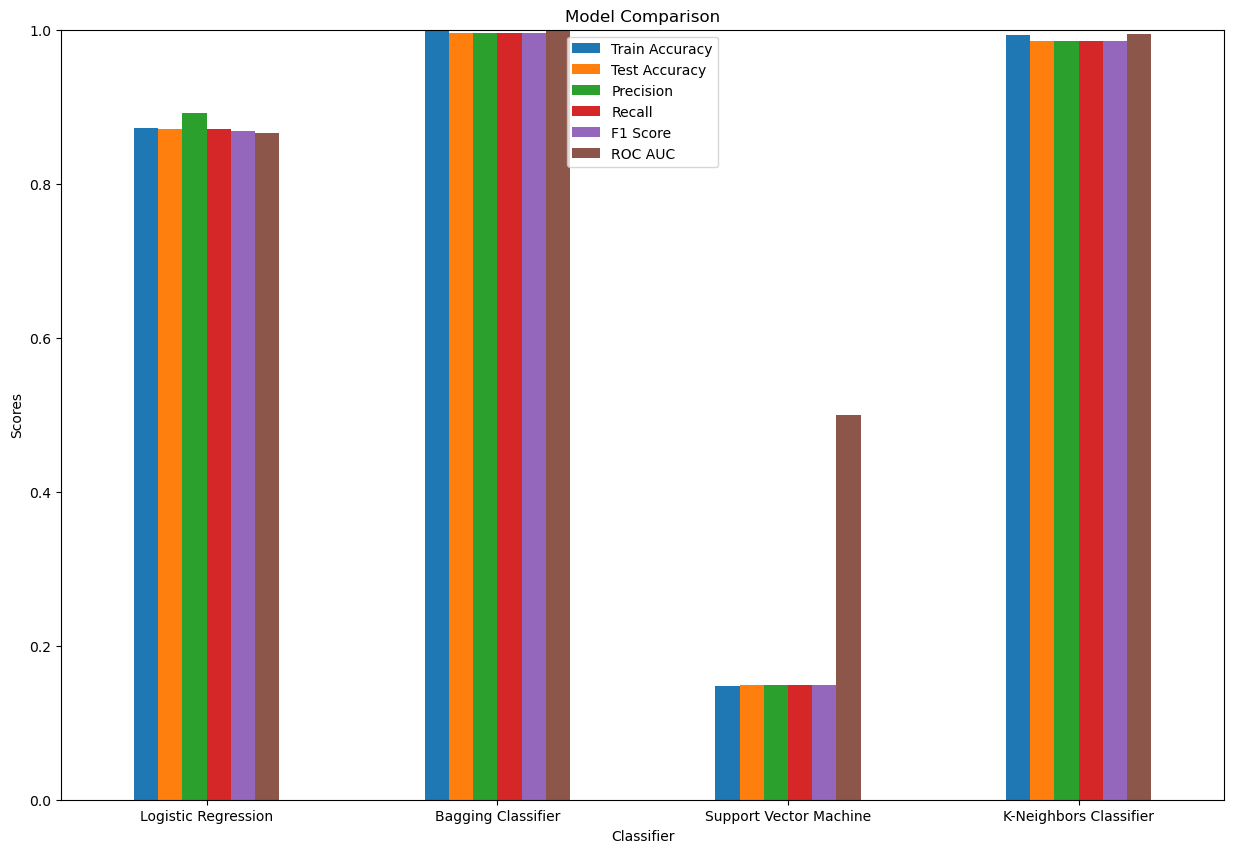

In [52]:
plt.figure(figsize=(15, 10))
results_df.plot(kind='bar', figsize=(15, 10))
plt.title('Model Comparison')
plt.xlabel('Classifier')
plt.ylabel('Scores')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

### Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train on your dataset
rf_model.fit(x_train, y_train)

# Predict
y_pred = rf_model.predict(x_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9958325064496923
Classification Report:
               precision    recall  f1-score   support

     anomaly       1.00      0.99      1.00      2349
      normal       0.99      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



### RF checking

In [55]:
input_data_normal = [
    [0.009, 0.03, 2, 0.3546, 0.32, 1, 19, 9, 0.772, 0.3, 0.7, 0.28]  
]
input_data_anomaly = [
    [0.01, 0.03, 13, 0.36, 0.73, 1, 46, 5, 1.3, 0.04, 0.93, 0.17]  
]

normal = rf_model.predict(input_data_normal)
anomaly = rf_model.predict(input_data_anomaly)

print(f"Prediction for normal input: {normal}")
print(f"Prediction for anomaly input: {anomaly}")


Prediction for normal input: ['normal']
Prediction for anomaly input: ['anomaly']


In [57]:
test_cases = np.array([
    [0.009, 0.03, 2, 0.3546, 0.32, 1, 19, 9, 0.772, 0.3, 0.7, 0.28],  # Normal
    [0.01, 0.03, 13, 0.36, 0.73, 1, 46, 5, 1.3, 0.04, 0.93, 0.17],  # Anomaly
    [0.02, 0.06, 20, 0.8, 1.0, 2, 30, 6, 1.5, 0.02, 0.9, 0.1],  # Anomaly 
])

predictions = rf_model.predict(test_cases)
print("Predictions:", predictions)


Predictions: ['normal' 'anomaly' 'anomaly']


In [58]:
import pickle

In [59]:
with open(r"C:\Users\Test\OneDrive\Desktop\website\rf.pkl","wb") as file:
    pickle.dump(rf_model,file)

In [63]:
# pip install scikit-learn==1.6.1

     ---------------------------------------- 11.2/11.2 MB 2.1 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.0.2
    Uninstalling scikit-learn-1.0.2:
      Successfully uninstalled scikit-learn-1.0.2
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Test\\anaconda3\\Lib\\site-packages\\~klearn\\decomposition\\_cdnmf_fast.cp39-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [56]:
# pip install numpy==1.26.4

In [57]:
# pip list